# 📈 CODTECH IT Solutions — Data Analytics Internship
## Task 1: Sales Trend Visualization

| Field | Details |
|-------|--------|
| **Name** |MD SAHIL ANSARI |
| **Intern ID** | CITS3147 |
| **Domain** | Data Analytics |
| **Duration** | 4 Weeks |
| **Mentor** | NEELA SANTHOSH KUMAR |
| **Company** | CODTECH IT Solutions Pvt. Ltd. |

---

### 🎯 Objective
Analyze and visualize **sales trends** across time, categories, regions, and customer segments to derive actionable business insights.

### 📌 Analysis Sections
1. Import Libraries & Load Data
2. Dataset Overview
3. Monthly & Yearly Sales Trend
4. Category-wise Sales Analysis
5. Regional Sales Analysis
6. Profit & Discount Analysis
7. Customer Segment Analysis
8. Top Products Analysis
9. Key Insights Summary

## Step 1 — Import Libraries & Load Data

In [2]:
# !pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [3]:
df = pd.read_csv('sales_data.csv', parse_dates=['date'])
print(f'Dataset Shape : {df.shape}')
df.head(10)

Dataset Shape : (500, 17)


,order_id,date,month,quarter,year,category,sub_category,product,region,state,city,customer_segment,sales,quantity,discount,profit,shipping_cost
0,ORD0001,2021-08-17,Aug,Q3,2021,Electronics,Electronics > Tablet,Tablet,South,Chennai,Chennai,Consumer,13597.30,2,0.36,662.08,95.95
1,ORD0002,2021-03-03,Mar,Q1,2021,Electronics,Electronics > Laptop,Laptop,South,Hyderabad,Hyderabad,Home Office,5655.76,1,0.29,1045.65,95.51
2,ORD0003,2023-07-09,Jul,Q3,2023,Sports,Sports > Yoga Mat,Yoga Mat,North,Delhi,Delhi,Home Office,24276.98,7,0.06,7694.20,80.59
3,ORD0004,2021-07-09,Jul,Q3,2021,Groceries,Groceries > Rice,Rice,East,Bhubaneswar,Bhubaneswar,Home Office,40448.80,5,0.29,6055.86,195.16
4,ORD0005,2023-02-15,Feb,Q1,2023,Electronics,Electronics > Smart Watch,Smart Watch,East,Patna,Patna,Home Office,34891.26,6,0.28,1601.44,61.02
5,ORD0006,2022-08-16,Aug,Q3,2022,Electronics,Electronics > Laptop,Laptop,North,Chandigarh,Chandigarh,Corporate,51141.12,8,0.15,7001.02,57.71
6,ORD0007,2022-07-01,Jul,Q3,2022,Electronics,Electronics > Smart Watch,Smart Watch,South,Hyderabad,Hyderabad,Home Office,6870.08,4,0.15,2025.50,135.20
7,ORD0008,2022-03-26,Mar,Q1,2022,Clothing,Clothing > T-Shirt,T-Shirt,South,Chennai,Chennai,Corporate,19252.59,7,0.08,5895.97,177.75
8,ORD0009,2022-10-07,Oct,Q4,2022,Furniture,Furniture > Sofa,Sofa,West,Ahmedabad,Ahmedabad,Corporate,8166.15,3,0.10,1605.22,67.29
9,ORD0010,2023-05-28,May,Q2,2023,Sports,Sports > Dumbbells,Dumbbells,East,Kolkata,Kolkata,Consumer,44867.79,9,0.30,9683.89,47.51


## Step 2 — Dataset Overview

In [4]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())

--- Data Types ---
order_id                       str
date                datetime64[us]
month                          str
quarter                        str
year                         int64
category                       str
sub_category                   str
product                        str
region                         str
state                          str
city                           str
customer_segment               str
sales                      float64
quantity                     int64
discount                   float64
profit                     float64
shipping_cost              float64
dtype: object

--- Missing Values ---
order_id            0
date                0
month               0
quarter             0
year                0
category            0
sub_category        0
product             0
region              0
state               0
city                0
customer_segment    0
sales               0
quantity            0
discount            0
profit            

In [5]:
print('--- Statistical Summary ---')
df[['sales','quantity','discount','profit','shipping_cost']].describe().round(2)

--- Statistical Summary ---


,sales,quantity,discount,profit,shipping_cost
count,500.00,500.00,500.00,500.00,500.00
mean,28385.78,5.66,0.21,4423.61,110.99
std,23325.11,2.85,0.12,4584.21,52.00
min,217.01,1.00,0.00,44.78,20.69
25%,8982.50,3.00,0.10,1073.62,65.22
50%,22633.32,6.00,0.22,2938.47,114.83
75%,42896.78,8.00,0.31,5896.62,153.33
max,99606.10,10.00,0.40,26858.34,199.92


In [6]:
total_sales  = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = len(df)
avg_order    = df['sales'].mean()
profit_margin = (total_profit / total_sales) * 100

print('='*50)
print('        📊 KEY METRICS')
print('='*50)
print(f'  Total Orders   : {total_orders:,}')
print(f'  Total Sales    : ₹{total_sales:,.2f}')
print(f'  Total Profit   : ₹{total_profit:,.2f}')
print(f'  Avg Order Value: ₹{avg_order:,.2f}')
print(f'  Profit Margin  : {profit_margin:.2f}%')
print('='*50)

        📊 KEY METRICS
  Total Orders   : 500
  Total Sales    : ₹14,192,890.36
  Total Profit   : ₹2,211,804.00
  Avg Order Value: ₹28,385.78
  Profit Margin  : 15.58%


## Step 3 — Monthly & Yearly Sales Trend

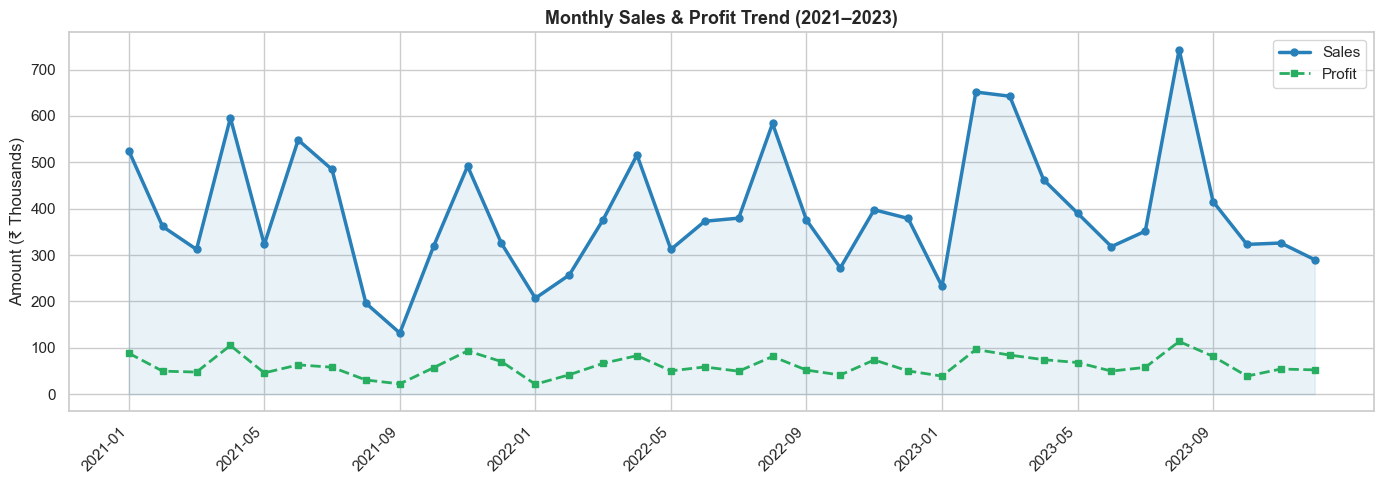

In [7]:
# Monthly trend
df['year_month'] = df['date'].dt.to_period('M')
monthly = df.groupby('year_month')[['sales','profit']].sum().reset_index()
monthly['year_month'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(monthly)), monthly['sales'] / 1e3,
        color='#2980B9', linewidth=2.5, marker='o', markersize=5, label='Sales')
ax.plot(range(len(monthly)), monthly['profit'] / 1e3,
        color='#27AE60', linewidth=2, marker='s', markersize=4, linestyle='--', label='Profit')
ax.fill_between(range(len(monthly)), monthly['sales'] / 1e3, alpha=0.1, color='#2980B9')
step = max(1, len(monthly) // 8)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly['year_month'].iloc[::step], rotation=45, ha='right')
ax.set_ylabel('Amount (₹ Thousands)')
ax.set_title('Monthly Sales & Profit Trend (2021–2023)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

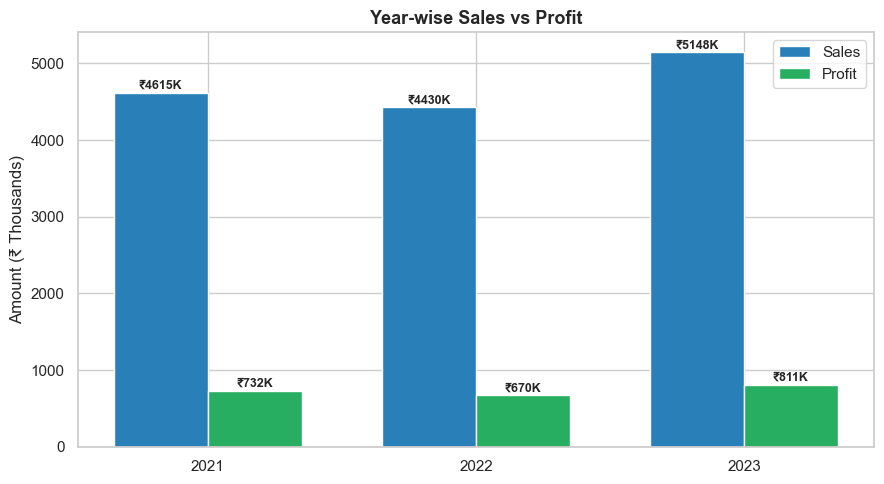

In [8]:
# Yearly comparison
yearly = df.groupby('year')[['sales','profit']].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(yearly))
w = 0.35
ax.bar(x - w/2, yearly['sales'] / 1e3, w, label='Sales', color='#2980B9', edgecolor='white')
ax.bar(x + w/2, yearly['profit'] / 1e3, w, label='Profit', color='#27AE60', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(yearly['year'].astype(str))
ax.set_ylabel('Amount (₹ Thousands)')
ax.set_title('Year-wise Sales vs Profit', fontsize=13, fontweight='bold')
ax.legend()
for i, (s, p) in enumerate(zip(yearly['sales'], yearly['profit'])):
    ax.text(i - w/2, s/1e3 + 50, f'₹{s/1e3:.0f}K', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, p/1e3 + 50, f'₹{p/1e3:.0f}K', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

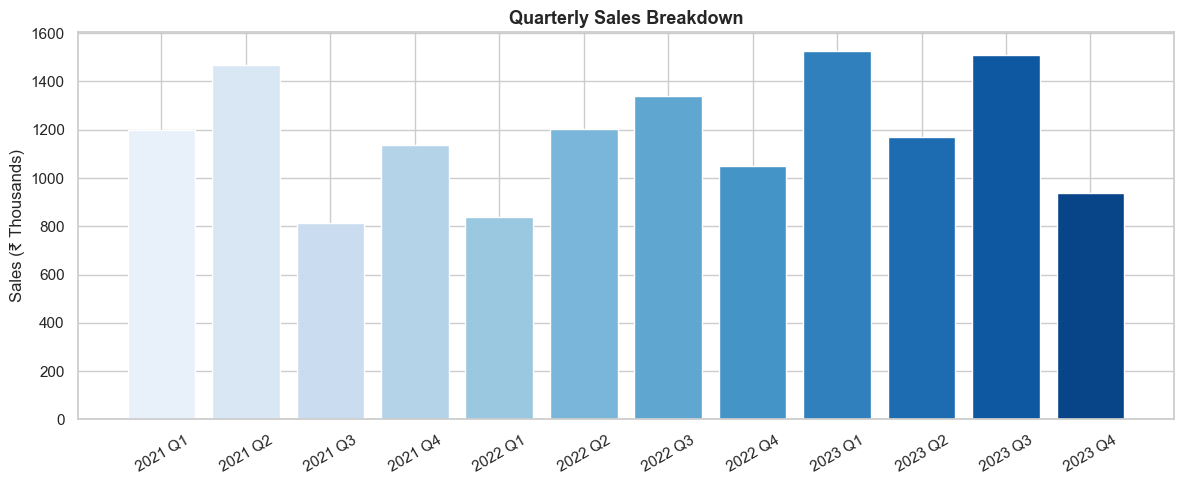

In [9]:
# Quarterly trend
qtr = df.groupby(['year','quarter'])['sales'].sum().reset_index()
qtr['label'] = qtr['year'].astype(str) + ' ' + qtr['quarter']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(qtr['label'], qtr['sales'] / 1e3,
       color=sns.color_palette('Blues', len(qtr)), edgecolor='white')
ax.set_ylabel('Sales (₹ Thousands)')
ax.set_title('Quarterly Sales Breakdown', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Step 4 — Category-wise Sales Analysis

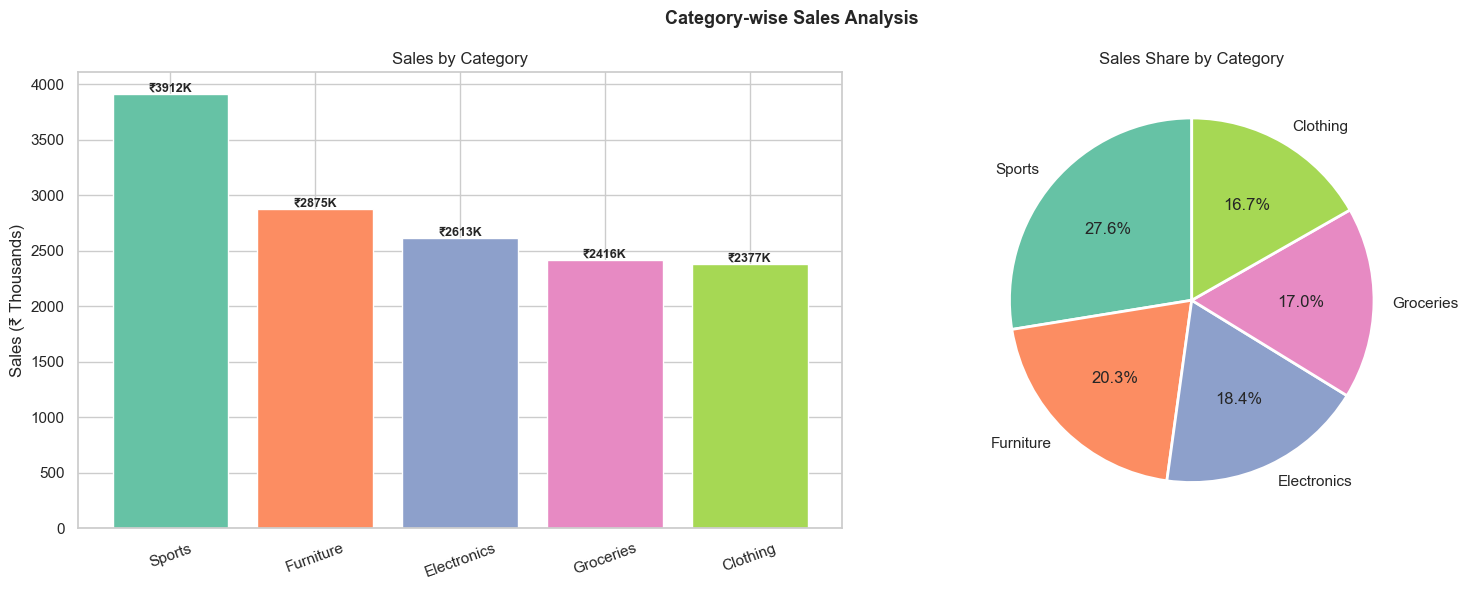

In [10]:
cat_sales = df.groupby('category')[['sales','profit']].sum().sort_values('sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Category-wise Sales Analysis', fontsize=13, fontweight='bold')

# Bar chart
colors = sns.color_palette('Set2', len(cat_sales))
bars = axes[0].bar(cat_sales.index, cat_sales['sales'] / 1e3,
                   color=colors, edgecolor='white')
axes[0].set_ylabel('Sales (₹ Thousands)')
axes[0].set_title('Sales by Category')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, cat_sales['sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'₹{val/1e3:.0f}K', ha='center', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(cat_sales['sales'], labels=cat_sales.index,
             autopct='%1.1f%%', colors=colors,
             wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[1].set_title('Sales Share by Category')

plt.tight_layout()
plt.show()

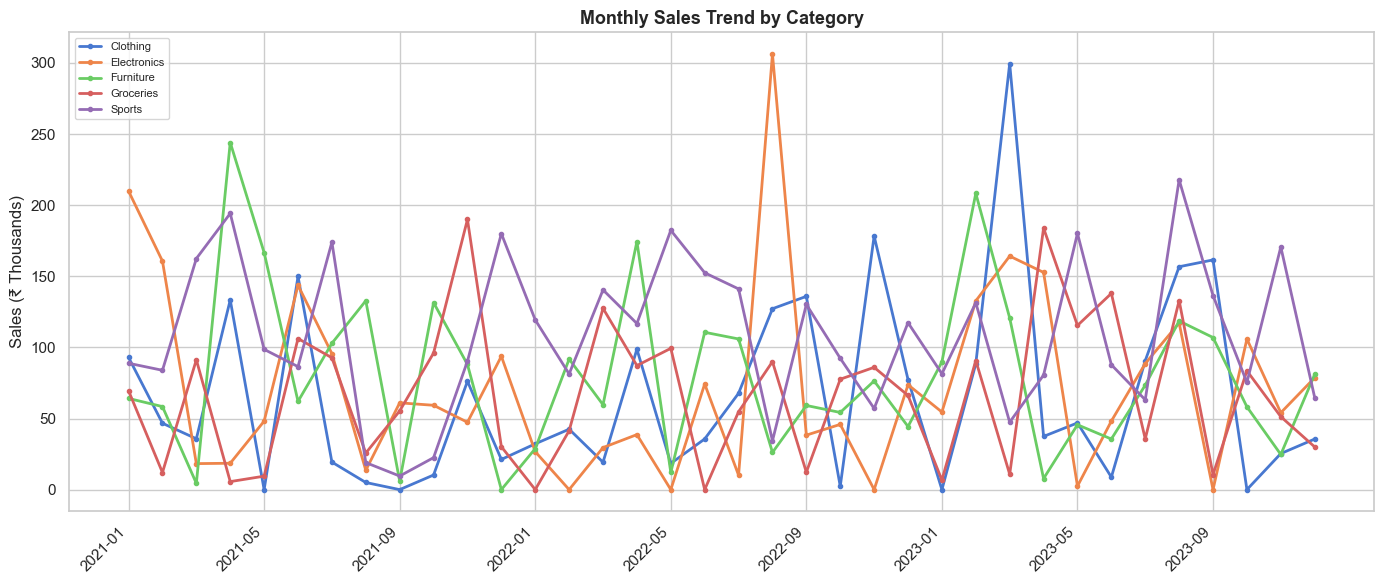

In [11]:
# Category trend over months
cat_monthly = df.groupby(['year_month','category'])['sales'].sum().reset_index()
cat_monthly['year_month'] = cat_monthly['year_month'].astype(str)
pivot = cat_monthly.pivot(index='year_month', columns='category', values='sales').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for i, col in enumerate(pivot.columns):
    ax.plot(range(len(pivot)), pivot[col] / 1e3, linewidth=2, label=col,
            marker='o', markersize=3)
step = max(1, len(pivot) // 8)
ax.set_xticks(range(0, len(pivot), step))
ax.set_xticklabels(pivot.index[::step], rotation=45, ha='right')
ax.set_ylabel('Sales (₹ Thousands)')
ax.set_title('Monthly Sales Trend by Category', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Step 5 — Regional Sales Analysis

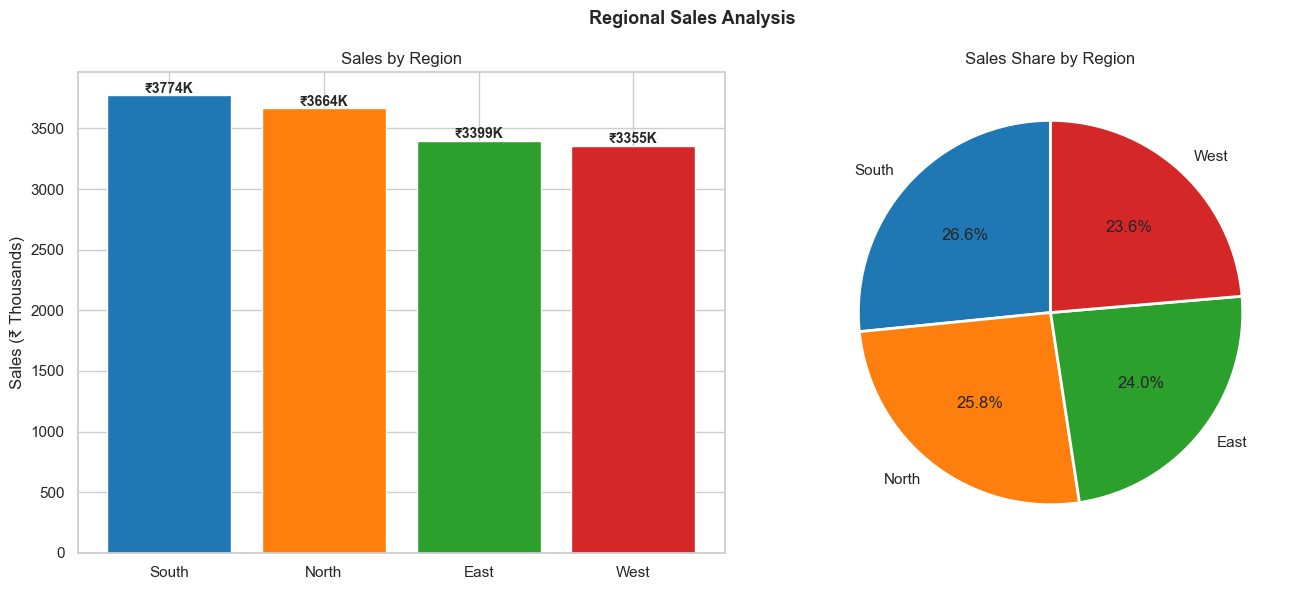

In [12]:
region_sales = df.groupby('region')[['sales','profit']].sum().sort_values('sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Regional Sales Analysis', fontsize=13, fontweight='bold')

region_colors = sns.color_palette('tab10', len(region_sales))
axes[0].bar(region_sales.index, region_sales['sales'] / 1e3,
             color=region_colors, edgecolor='white')
axes[0].set_ylabel('Sales (₹ Thousands)')
axes[0].set_title('Sales by Region')
for i, v in enumerate(region_sales['sales']):
    axes[0].text(i, v/1e3 + 20, f'₹{v/1e3:.0f}K', ha='center', fontsize=10, fontweight='bold')

axes[1].pie(region_sales['sales'], labels=region_sales.index,
             autopct='%1.1f%%', colors=region_colors,
             wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[1].set_title('Sales Share by Region')

plt.tight_layout()
plt.show()

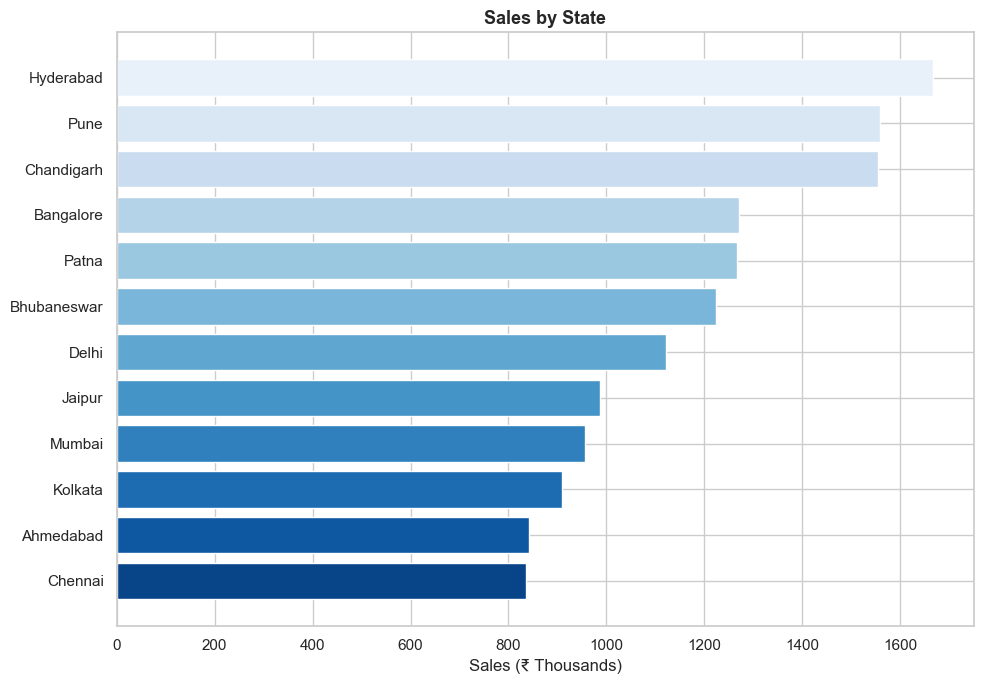

In [13]:
# State-wise sales
state_sales = df.groupby('state')['sales'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(state_sales.index, state_sales.values / 1e3,
        color=sns.color_palette('Blues_r', len(state_sales)))
ax.set_xlabel('Sales (₹ Thousands)')
ax.set_title('Sales by State', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Profit & Discount Analysis

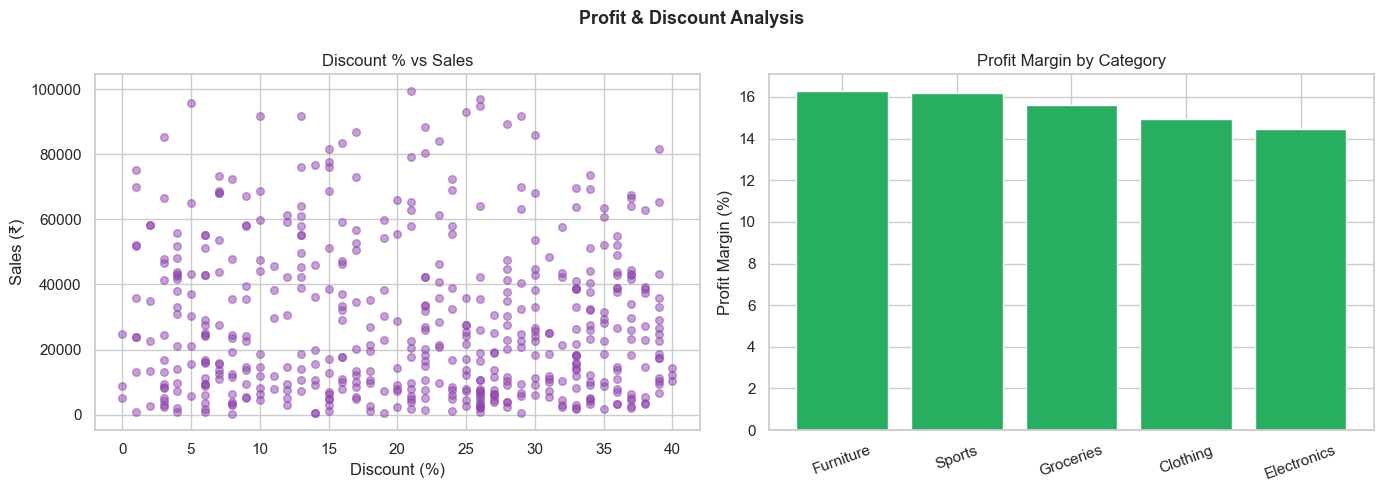

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Profit & Discount Analysis', fontsize=13, fontweight='bold')

# Discount vs Sales scatter
axes[0].scatter(df['discount'] * 100, df['sales'],
                alpha=0.5, color='#8E44AD', s=30)
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Sales (₹)')
axes[0].set_title('Discount % vs Sales')

# Profit margin by category
cat_margin = (df.groupby('category')['profit'].sum() /
              df.groupby('category')['sales'].sum() * 100).sort_values(ascending=False)
colors_m = ['#27AE60' if v > 0 else '#E74C3C' for v in cat_margin.values]
axes[1].bar(cat_margin.index, cat_margin.values, color=colors_m, edgecolor='white')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].set_title('Profit Margin by Category')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## Step 7 — Customer Segment Analysis

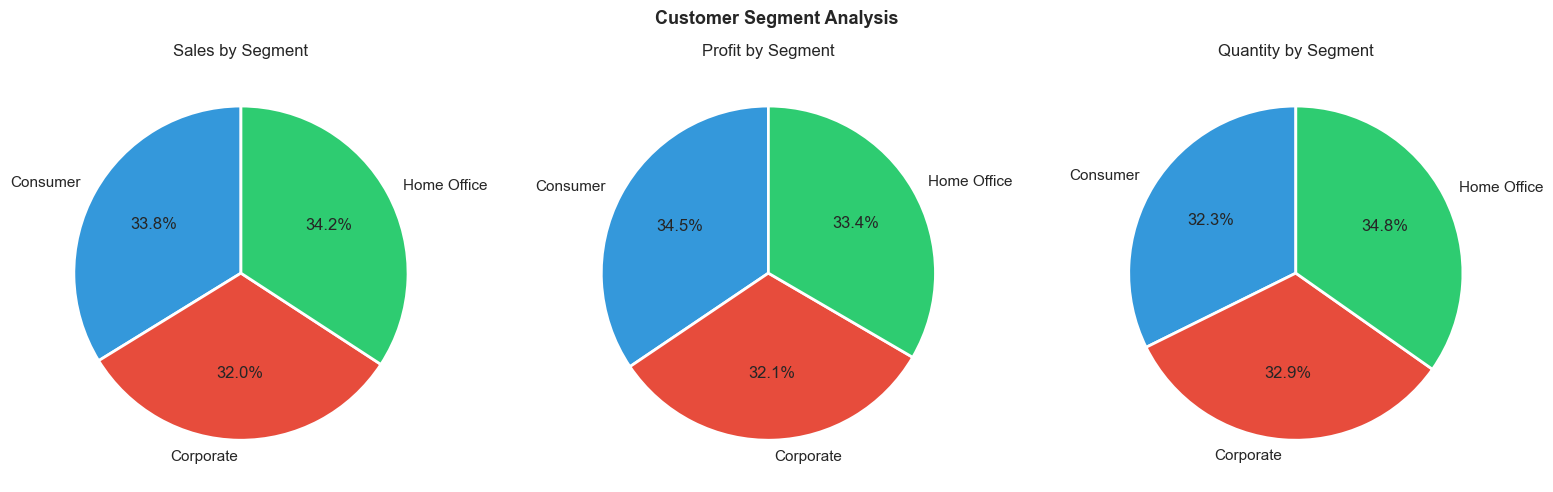

In [15]:
seg_data = df.groupby('customer_segment')[['sales','profit','quantity']].sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer Segment Analysis', fontsize=13, fontweight='bold')

seg_colors = ['#3498DB','#E74C3C','#2ECC71']
for ax, col, title in zip(axes,
    ['sales','profit','quantity'],
    ['Sales by Segment','Profit by Segment','Quantity by Segment']):
    ax.pie(seg_data[col], labels=seg_data.index,
           autopct='%1.1f%%', colors=seg_colors,
           wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Step 8 — Top Products Analysis

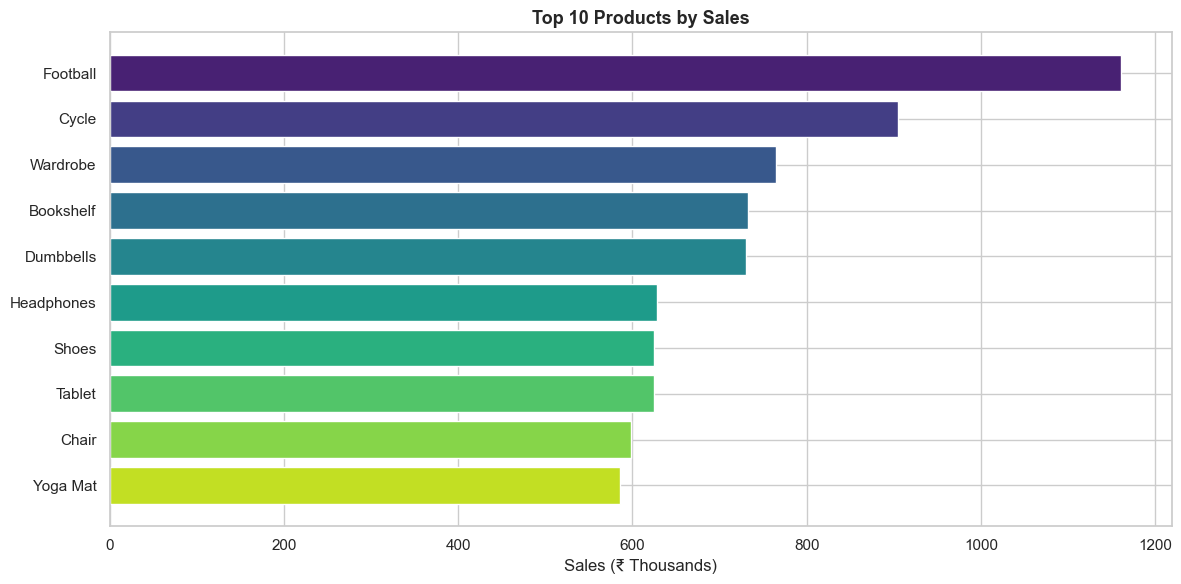

In [16]:
top_products = (df.groupby('product')['sales']
                  .sum().sort_values(ascending=False).head(10).reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_products['product'], top_products['sales'] / 1e3,
        color=sns.color_palette('viridis', 10))
ax.invert_yaxis()
ax.set_xlabel('Sales (₹ Thousands)')
ax.set_title('Top 10 Products by Sales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

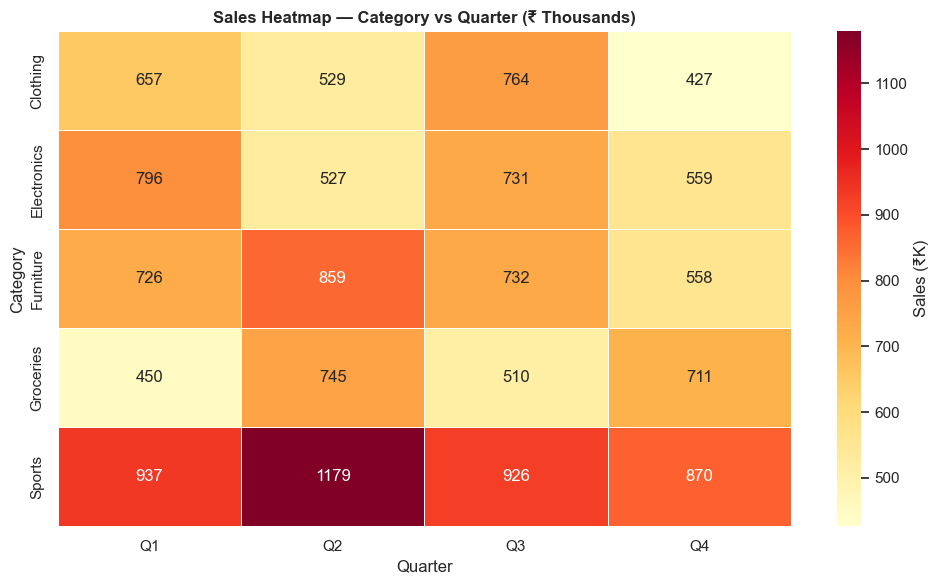

In [17]:
# Heatmap: Category vs Quarter
heat_data = df.groupby(['category','quarter'])['sales'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat_data / 1e3, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Sales (₹K)'})
ax.set_title('Sales Heatmap — Category vs Quarter (₹ Thousands)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

## Step 9 — Key Insights Summary

In [18]:
top_cat    = df.groupby('category')['sales'].sum().idxmax()
top_region = df.groupby('region')['sales'].sum().idxmax()
top_state  = df.groupby('state')['sales'].sum().idxmax()
top_seg    = df.groupby('customer_segment')['sales'].sum().idxmax()
top_prod   = df.groupby('product')['sales'].sum().idxmax()
best_month = monthly.loc[monthly['sales'].idxmax(), 'year_month']
best_year  = yearly.loc[yearly['sales'].idxmax(), 'year']

print('='*55)
print('      📊 KEY INSIGHTS — SALES TREND ANALYSIS')
print('='*55)
print(f'  Total Orders        : {total_orders:,}')
print(f'  Total Sales         : ₹{total_sales:,.2f}')
print(f'  Total Profit        : ₹{total_profit:,.2f}')
print(f'  Profit Margin       : {profit_margin:.2f}%')
print(f'  Avg Order Value     : ₹{avg_order:,.2f}')
print(f'  Top Category        : {top_cat}')
print(f'  Top Region          : {top_region}')
print(f'  Top State           : {top_state}')
print(f'  Top Customer Seg.   : {top_seg}')
print(f'  Top Product         : {top_prod}')
print(f'  Best Sales Month    : {best_month}')
print(f'  Best Sales Year     : {best_year}')
print('='*55)
print('\n✅  Task 1 Complete!')

      📊 KEY INSIGHTS — SALES TREND ANALYSIS
  Total Orders        : 500
  Total Sales         : ₹14,192,890.36
  Total Profit        : ₹2,211,804.00
  Profit Margin       : 15.58%
  Avg Order Value     : ₹28,385.78
  Top Category        : Sports
  Top Region          : South
  Top State           : Hyderabad
  Top Customer Seg.   : Home Office
  Top Product         : Football
  Best Sales Month    : 2023-08
  Best Sales Year     : 2023

✅  Task 1 Complete!


---
*CODTECH IT Solutions Pvt. Ltd. — Data Analytics Internship — Task 1*